In [5]:



import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from prophet import Prophet


# Download Microsoft stock data from 2021 to 2026

df = yf.download(
    "MSFT",
    start="2021-01-01",
    end="2026-01-01"
)
print(df.head())


C:\Users\dhruv joshi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open    Volume
Ticker            MSFT        MSFT        MSFT        MSFT      MSFT
Date                                                                
2021-01-04  208.406509  213.490060  205.649324  213.040102  37130100
2021-01-05  208.607574  209.201144  206.501397  207.994868  23823000
2021-01-06  203.198486  207.257675  202.901709  203.121896  35930700
2021-01-07  208.980957  209.986182  204.596285  204.912199  27694500
2021-01-08  210.254211  211.173278  207.774667  209.354296  22956200


In [6]:


# PREPARE DATA FOR PROPHET


# Reset index to make Date a column
df.reset_index(inplace=True)

# Keep only Date and Close columns
df = df[['Date', 'Close']]

# Rename columns for Prophet
df.columns = ['ds', 'y']

# Show dataset
print(df.head())



          ds           y
0 2021-01-04  208.406509
1 2021-01-05  208.607574
2 2021-01-06  203.198486
3 2021-01-07  208.980957
4 2021-01-08  210.254211


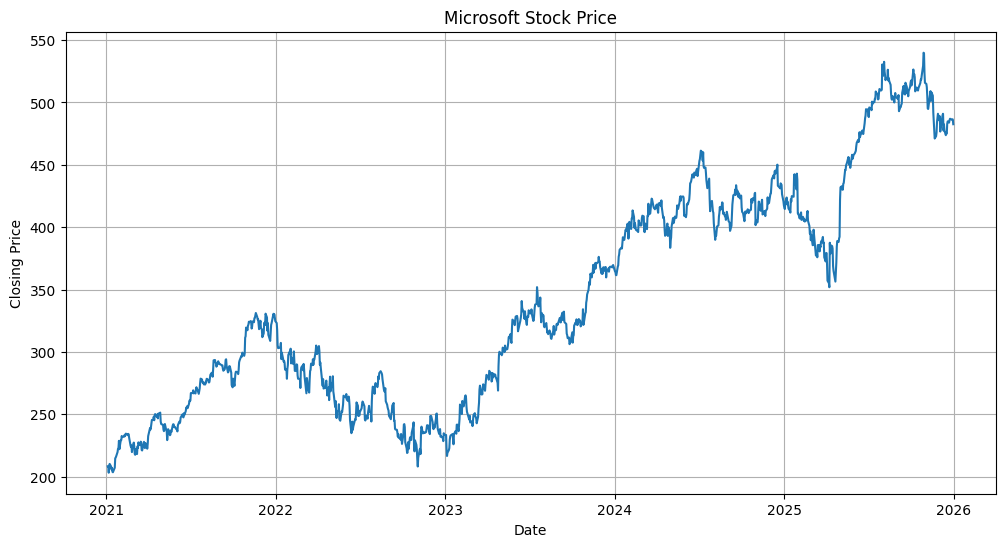

12:51:53 - cmdstanpy - INFO - Chain [1] start processing
12:51:54 - cmdstanpy - INFO - Chain [1] done processing


In [7]:
# VISUALIZE STOCK PRICE

plt.figure(figsize=(12,6))
plt.plot(df['ds'], df['y'])
plt.title('Microsoft Stock Price')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.grid(True)
plt.show()


# CREATE AND TRAIN PROPHET MODEL


model = Prophet(
    daily_seasonality=True,
    yearly_seasonality=True
)

model.fit(df)



In [8]:

# . CREATE FUTURE DATES

# Predict next 365 days
future = model.make_future_dataframe(periods=365)


# . MAKE PREDICTIONS

forecast = model.predict(future)

# Show prediction columns
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail())




             ds        yhat  yhat_lower  yhat_upper
1615 2026-12-27  608.431729  501.696734  709.489062
1616 2026-12-28  610.876724  505.116279  710.469470
1617 2026-12-29  610.239678  503.945221  714.432642
1618 2026-12-30  610.192011  506.107560  710.862681
1619 2026-12-31  610.089305  503.960891  714.760538


TypeError: show() got an unexpected keyword argument 'color'

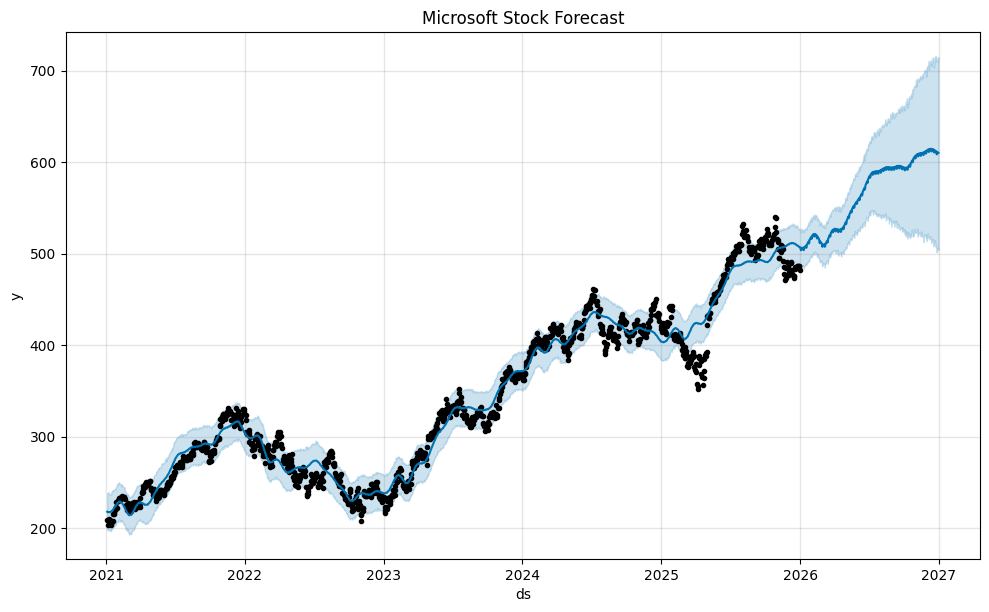

In [ ]:
# . PLOT FORECAST


fig1 = model.plot(forecast )
plt.title("Microsoft Stock Forecast" )
plt.show()





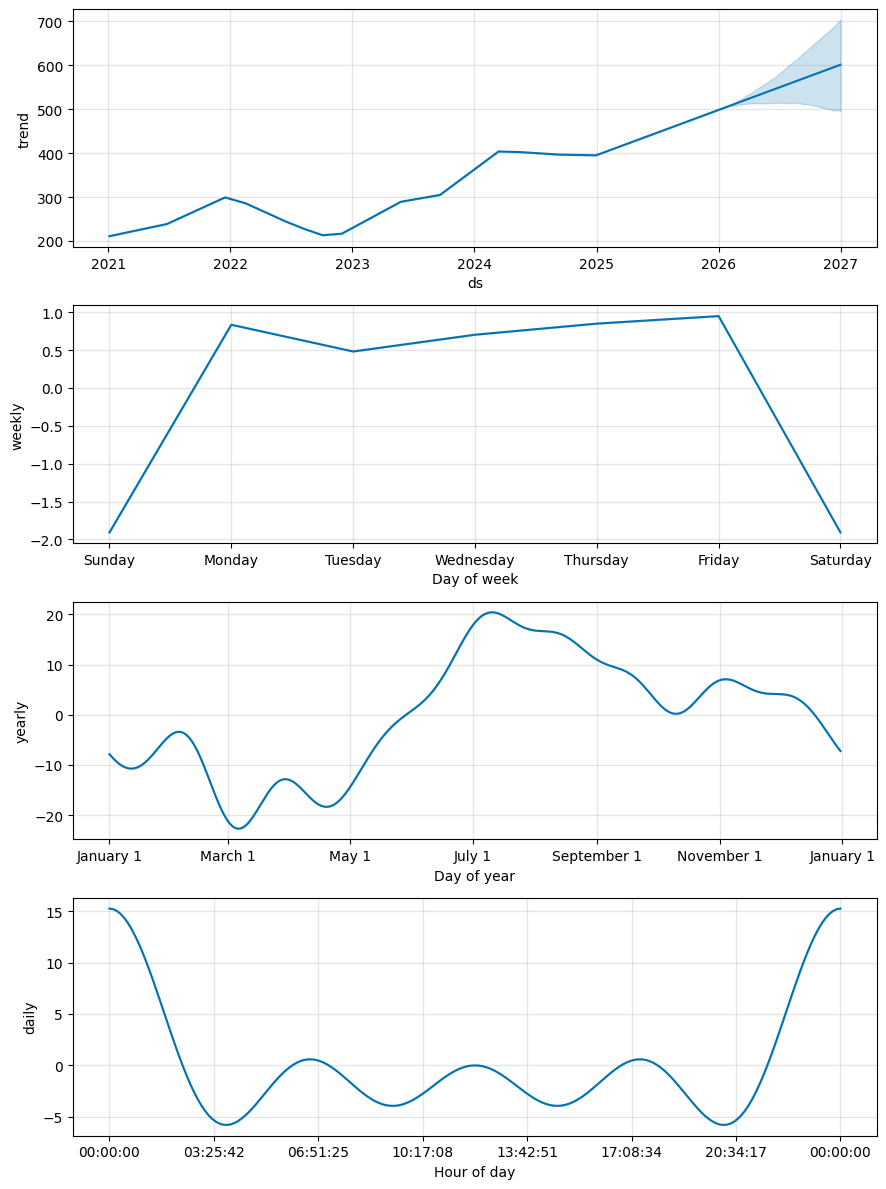

In [11]:

# . PLOT FORECAST COMPONENTS


fig2 = model.plot_components(forecast)
plt.show()